# Train your first Gated Sparse Autoencoder (TensorFlow / Keras)

This notebook **trains a sparse gated autoencoder from scratch** on Fashion MNIST.
We are *not* inspecting a pre-trained network here — we are training the SAE's own
encoder and decoder directly on the pixel data so that its dictionary learns the
underlying shapes and strokes that reconstruct the images with as few active features
as possible. Once trained, the decoder directions and their top-activating images let
us *see what the dictionary learned*.

Most open-source SAE tooling is PyTorch; [`gated-sae-tf`](https://github.com/aishwaryanatesh-hub/gated-sae-tf)
is a TensorFlow/Keras implementation of the **gated** SAE from
[Rajamanoharan et al. (2024)](https://arxiv.org/abs/2404.16014).

**Further reading**
- Rajamanoharan et al. (2024), *Improving Dictionary Learning with Gated Sparse Autoencoders*, [arXiv:2404.16014](https://arxiv.org/abs/2404.16014) — the architecture this library implements.
- Bricken et al. (2023), [*Towards Monosemanticity*](https://transformer-circuits.pub/2023/monosemantic-features).
- Templeton et al. (2024), [*Scaling Monosemanticity*](https://transformer-circuits.pub/2024/scaling-monosemanticity/index.html).
- Elhage et al. (2022), [*Toy Models of Superposition*](https://transformer-circuits.pub/2022/toy_model/index.html).

Install: `pip install "gated-sae-tf[viz]"`

In [1]:
import keras
import numpy as np
import matplotlib.pyplot as plt

from gated_sae import (
    GatedSAE,
    WarmupCosineDecay,
    sparsity_report,
    decoder_sharpness,
    plot_feature_gallery,
)

keras.utils.set_random_seed(1729)

## 1. Data — public Fashion MNIST

We use `keras.datasets.fashion_mnist` (downloaded on first run), flatten to 784-dim
vectors, scale to `[0, 1]`, and compute the training-set mean to initialize `b_dec`.

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

X_train = x_train.reshape(-1, 784).astype('float32') / 255.0
X_test  = x_test.reshape(-1, 784).astype('float32') / 255.0
train_mean = X_train.mean(axis=0)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print('Train:', X_train.shape, '| Test:', X_test.shape)

    0/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


       0/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   49152/26421880 ━━━━━━━━━━━━━━━━━━━━ 1:01 2us/step

   81920/26421880 ━━━━━━━━━━━━━━━━━━━━ 1:08 3us/step

...

1507328/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

2252800/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

3334144/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Train: (60000, 784) | Test: (10000, 784)


## 2. Hyperparameters

A **fast-demo** config (small dictionary, few epochs) so the notebook runs in a few
minutes on CPU. The commented **full config** mirrors the research recipe (16x
overcomplete, 200 epochs) for users with a GPU.

In [3]:
INPUT_DIM    = 784

# ── Fast-demo config (runs on CPU) ──────────────────────────────
ENCODING_DIM = INPUT_DIM * 4      # 4x overcomplete (3,136 features)
BATCH_SIZE   = 256
EPOCHS       = 15
WARMUP_FRAC  = 0.1
LAMBDA_SWEEP = [5e-4, 2e-3]       # two values to find the sharper dictionary

# ── Full research config (needs a GPU) ──────────────────────────
# ENCODING_DIM = INPUT_DIM * 16   # 12,544 features
# EPOCHS       = 200
# LAMBDA_SWEEP = [5e-4, 1e-3, 3e-3]

PEAK_LR    = 1e-3
AUX_WEIGHT = 0.1
CLIP_NORM  = 1.0

## 3. Learning-rate schedule

Linear warmup then cosine decay to zero. The warmup stabilizes the early steps when
training Adam with `beta_1=0` (no momentum), as the report recommends.

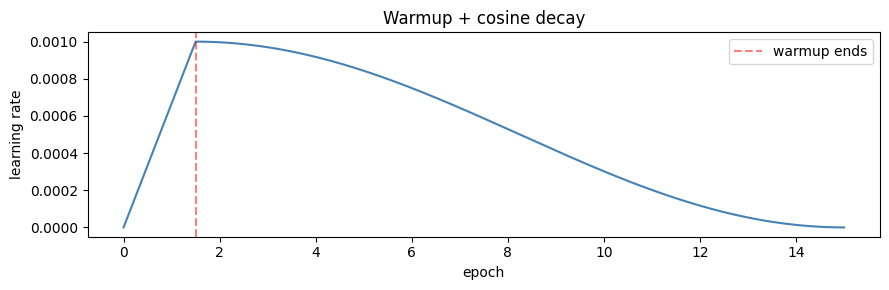

In [4]:
steps_per_epoch = len(X_train) // BATCH_SIZE
total_steps  = steps_per_epoch * EPOCHS
warmup_steps = int(total_steps * WARMUP_FRAC)

schedule = WarmupCosineDecay(PEAK_LR, warmup_steps, total_steps)
lrs = [float(schedule(s)) for s in range(total_steps)]

plt.figure(figsize=(9, 3))
plt.plot(np.arange(total_steps) / steps_per_epoch, lrs, color='steelblue')
plt.axvline(warmup_steps / steps_per_epoch, ls='--', color='red', alpha=0.5, label='warmup ends')
plt.xlabel('epoch'); plt.ylabel('learning rate'); plt.legend(); plt.title('Warmup + cosine decay')
plt.tight_layout(); plt.show()

## 4. Train — a small lambda sweep

We train one model per sparsity weight. Each gets a fresh LR schedule, `b_dec`
initialized to the data mean, and Adam with `beta_1=0`.

In [5]:
results = {}

for lam in LAMBDA_SWEEP:
    tag = f'lambda_{lam:.0e}'
    print(f'\n=== Training {tag} ===')

    model = GatedSAE(INPUT_DIM, ENCODING_DIM, lambda_sparse=lam,
                     aux_weight=AUX_WEIGHT, clip_norm=CLIP_NORM, name=tag)
    model(X_train[:2])                 # build weights
    model.b_dec.assign(train_mean)     # init decoder bias to data mean

    lr = WarmupCosineDecay(PEAK_LR, warmup_steps, total_steps)
    model.compile(optimizer=keras.optimizers.Adam(lr, beta_1=0.0, beta_2=0.999))

    history = model.fit(X_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
                        validation_data=(X_test,), verbose=2)
    results[tag] = {'model': model, 'history': history.history, 'lambda': lam}


=== Training lambda_5e-04 ===
Epoch 1/15


235/235 - 5s - 23ms/step - L_aux: 13.2437 - L_reconstruct: 13.1927 - L_sparsity: 116.9431 - grad_norm: 23.3748 - loss: 14.5755 - val_L_aux: 18.2474 - val_L_reconstruct: 17.8940 - val_L_sparsity: 149.2839 - val_loss: 19.7934


Epoch 2/15


235/235 - 5s - 20ms/step - L_aux: 9.3207 - L_reconstruct: 8.9113 - L_sparsity: 76.2025 - grad_norm: 16.8237 - loss: 9.8814 - val_L_aux: 11.8513 - val_L_reconstruct: 11.3397 - val_L_sparsity: 82.1028 - val_loss: 12.5659


Epoch 3/15


...

235/235 - 5s - 22ms/step - L_aux: 1.4483 - L_reconstruct: 1.1619 - L_sparsity: 51.4091 - grad_norm: 1.7808 - loss: 1.4096 - val_L_aux: 3.5038 - val_L_reconstruct: 2.6691 - val_L_sparsity: 61.8931 - val_loss: 3.1433


Epoch 14/15


235/235 - 5s - 22ms/step - L_aux: 1.3892 - L_reconstruct: 1.1066 - L_sparsity: 51.9255 - grad_norm: 1.7024 - loss: 1.3493 - val_L_aux: 3.4169 - val_L_reconstruct: 2.6043 - val_L_sparsity: 62.5104 - val_loss: 3.0710


Epoch 15/15


235/235 - 5s - 23ms/step - L_aux: 1.3687 - L_reconstruct: 1.0878 - L_sparsity: 52.0517 - grad_norm: 1.6770 - loss: 1.3288 - val_L_aux: 3.4129 - val_L_reconstruct: 2.5929 - val_L_sparsity: 62.7194 - val_loss: 3.0596


## 5. Training curves

Reconstruction loss should fall while the gradient norm stays near the clip threshold.

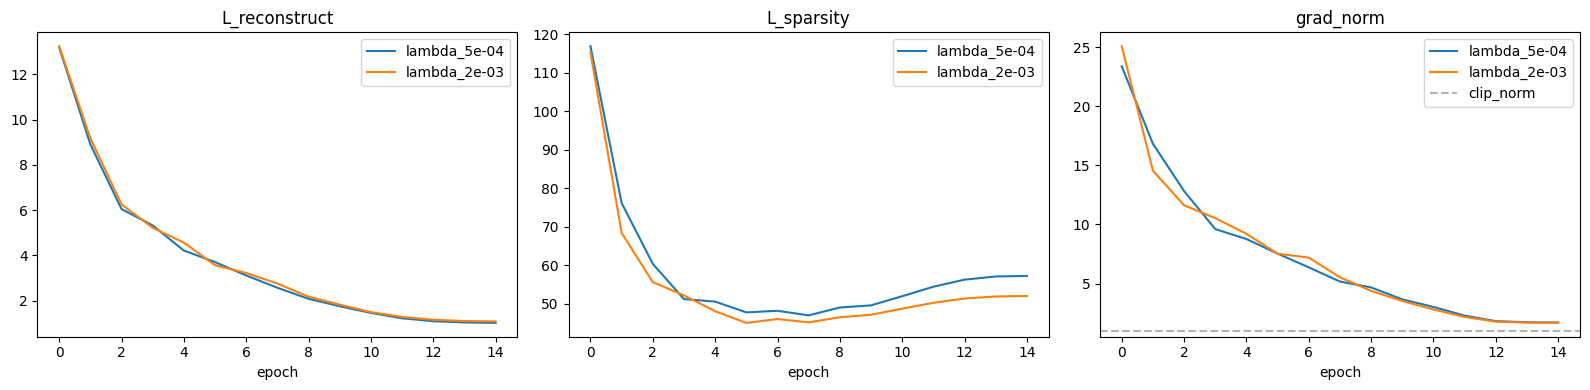

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for tag, r in results.items():
    h = r['history']
    axes[0].plot(h['L_reconstruct'], label=tag)
    axes[1].plot(h['L_sparsity'], label=tag)
    axes[2].plot(h['grad_norm'], label=tag)
axes[0].set_title('L_reconstruct'); axes[1].set_title('L_sparsity'); axes[2].set_title('grad_norm')
axes[2].axhline(CLIP_NORM, ls='--', color='gray', alpha=0.6, label='clip_norm')
for ax in axes: ax.set_xlabel('epoch'); ax.legend()
plt.tight_layout(); plt.show()

## 6. Sparsity statistics

`sparsity_report` summarizes how many features fire per example (L0), how many are
alive vs dead, and how concentrated activation is in the top-20 features.

In [7]:
for tag, r in results.items():
    rep = sparsity_report(r['model'], X_train)
    print(f"{tag} (lambda={r['lambda']:.0e}):")
    print(f"  L0 mean={rep['l0_mean']:.1f}, median={rep['l0_median']:.1f}")
    print(f"  alive={rep['alive']}/{rep['n_features']} ({rep['alive_frac']*100:.1f}%), dead={rep['dead']}")
    print(f"  top-{rep['topk']} share = {rep['topk_share']*100:.1f}%\n")

lambda_5e-04 (lambda=5e-04):
  L0 mean=521.7, median=515.0
  alive=3136/3136 (100.0%), dead=0
  top-20 share = 12.9%



lambda_2e-03 (lambda=2e-03):
  L0 mean=474.5, median=465.0
  alive=3136/3136 (100.0%), dead=0
  top-20 share = 13.6%



## 7. Decoder sharpness

Per-feature kurtosis of the decoder directions. Higher kurtosis means a direction
concentrates on a few pixels — a sharper, more localized (often more interpretable)
feature. We pick the dictionary with the sharpest top features as our best model.

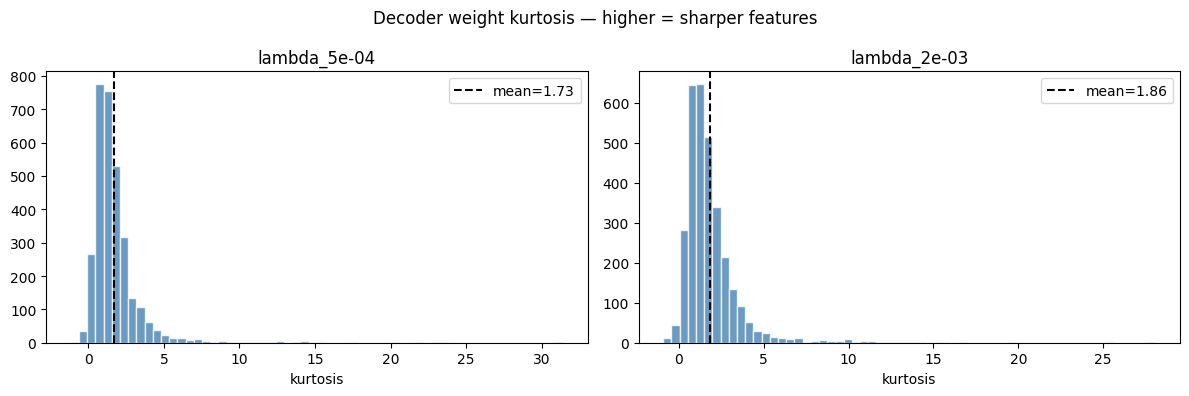

Sharpest dictionary: lambda_2e-03 (mean kurtosis 1.86)


In [8]:
fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 4), squeeze=False)
best_tag, best_kurt = None, -np.inf
for i, (tag, r) in enumerate(results.items()):
    per_feature, mean_kurt = decoder_sharpness(r['model'])
    axes[0][i].hist(per_feature, bins=60, color='steelblue', alpha=0.8, edgecolor='white')
    axes[0][i].axvline(mean_kurt, ls='--', color='black', label=f'mean={mean_kurt:.2f}')
    axes[0][i].set_title(tag); axes[0][i].set_xlabel('kurtosis'); axes[0][i].legend()
    if mean_kurt > best_kurt: best_kurt, best_tag = mean_kurt, tag
plt.suptitle('Decoder weight kurtosis — higher = sharper features'); plt.tight_layout(); plt.show()
print('Sharpest dictionary:', best_tag, f'(mean kurtosis {best_kurt:.2f})')

## 8. Feature gallery

For the sharpest model, show each top feature's decoder direction next to the images
that activate it most. `MONO` tags features whose top images share one class; `POLY`
tags features that span several classes.

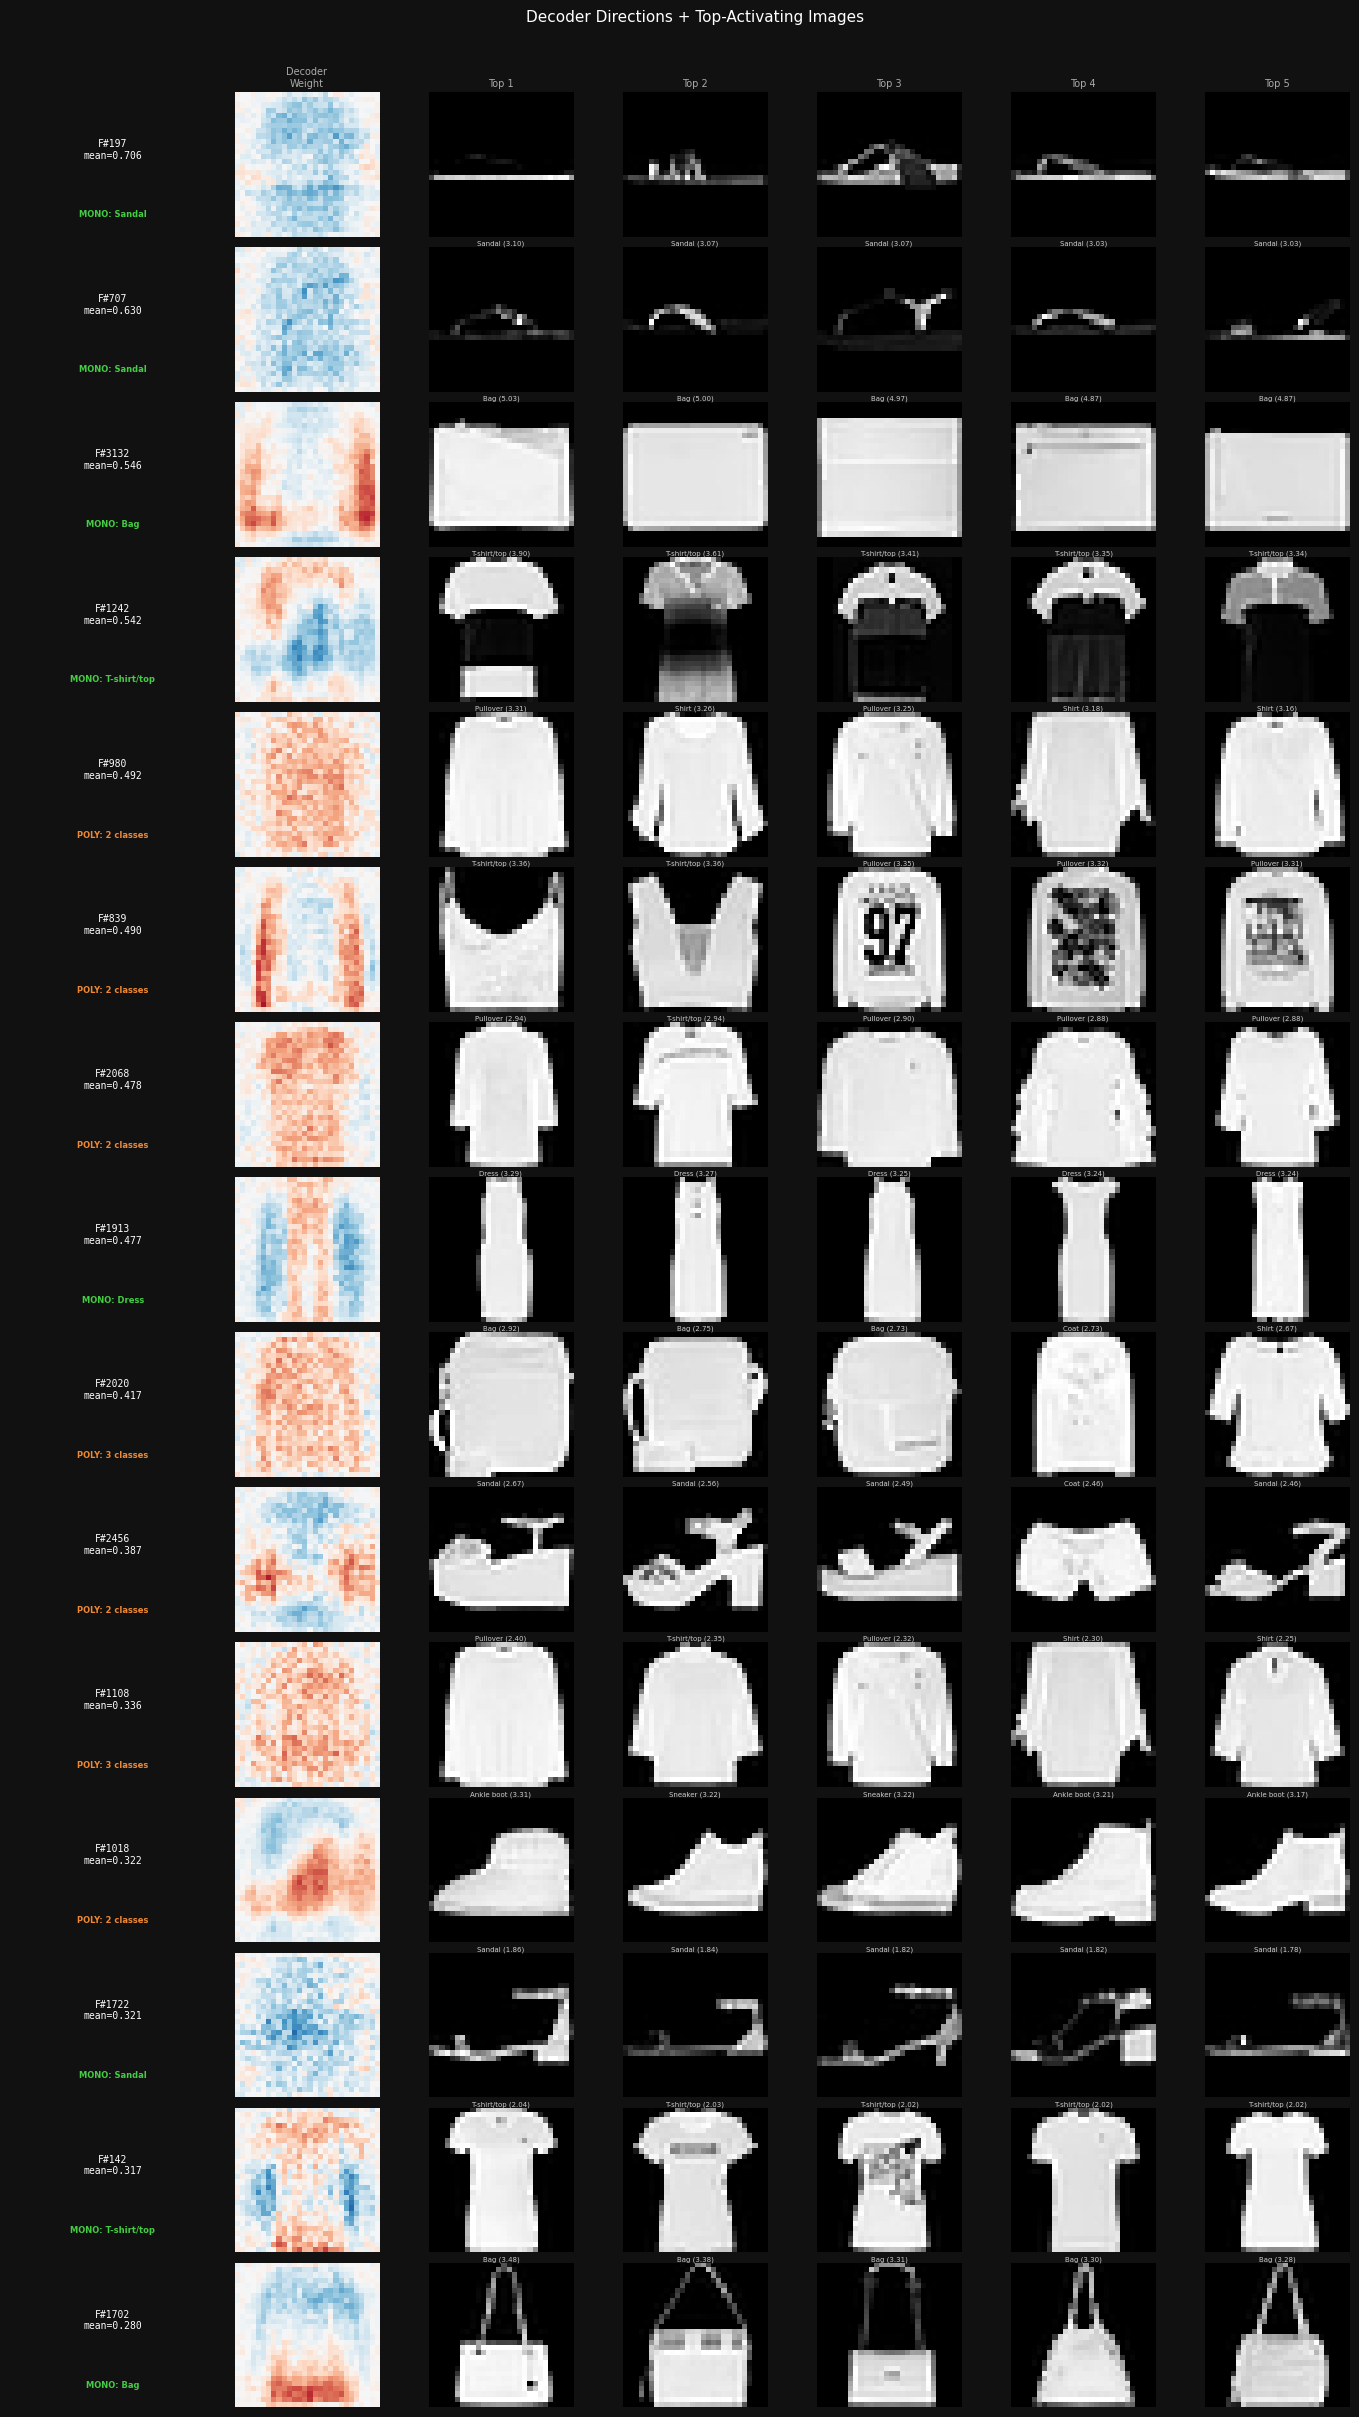

In [9]:
best = results[best_tag]['model']
codes, _, _ = best.encode(X_train)
codes = np.asarray(codes)

fig = plot_feature_gallery(best, codes, X_train, y_train, CLASS_NAMES,
                           top_features=15, top_images=5)
plt.show()

## What next?

- Bump to the full config (16x, 200 epochs) on a GPU for sharper, more monosemantic features.
- Run the SAE on the activations of *your own* model instead of raw pixels.
- Anneal sparsity during training via `model.set_lambda(...)`.

See the [README](https://github.com/aishwaryanatesh-hub/gated-sae-tf) for the full API.